<a href="https://colab.research.google.com/github/BrianLearning-source/PCVK_Genap_2026/blob/main/week03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**WEEK 3**

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
import numpy as np
import cv2 as cv
from google.colab.patches import cv2_imshow

Mengubah tingkat kecerahan citra
--------------------------------
Masukkan nilai kecerahan: 30


/tmp/ipykernel_1403/1909311761.py:14: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


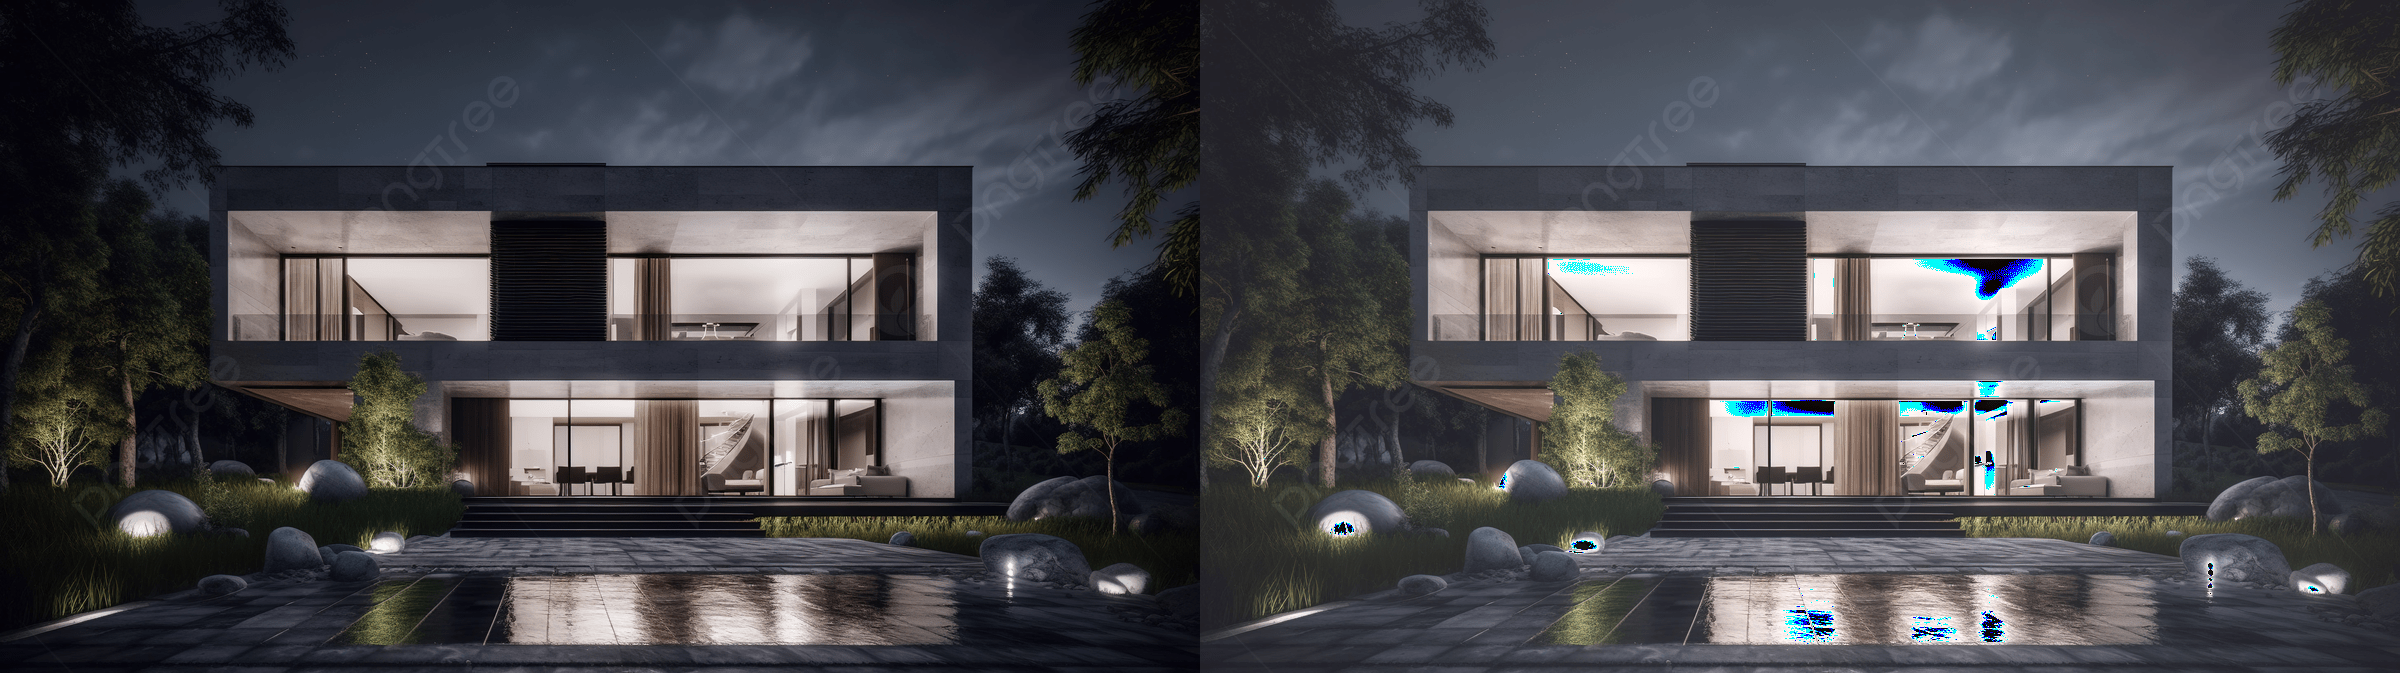

In [5]:
print('Mengubah tingkat kecerahan citra')
print('--------------------------------')
try:
  brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
  print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/modern_house.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

**TUGAS PRAKTIKUM**

1. Implementasikan inverse citra pada Google Colaboratory menggunakan formula yang
terdapat pada bagian Ulasan Teori, sehingga menghasilkan keluaran seperti berikut:

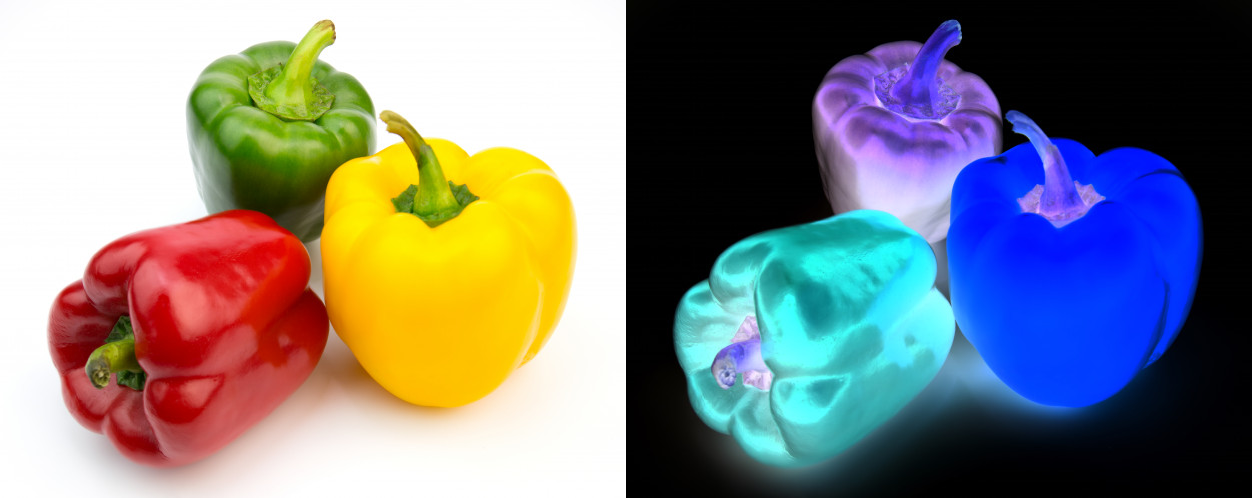

In [ ]:
original  = cv.imread('/content/drive/MyDrive/PCVK/peppers.jpg')
orignal = 255 - original

final_frame = cv.hconcat((original, orignal))
cv2_imshow(final_frame)

2. Implementasikan transformasi contrast pada Google Colaboratory menggunakan
formula yang terdapat pada bagian Ulasan Teori untuk kontras, sehingga
menghasilkan keluaran seperti berikut:

Mengubah kontras dan tingkat kecerahan citra
---------------------------------------------
Masukkan tingkat kecerahan : 10
Masukkan kontras : 1.5


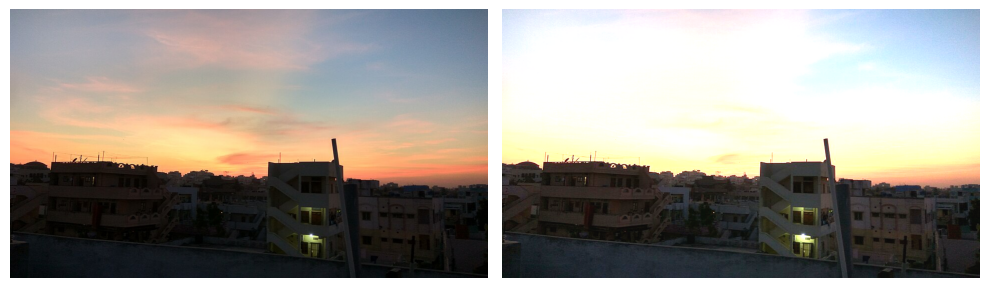

In [19]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

def truncate(val):
    if val > 255:
        return 255
    elif val < 0:
        return 0
    return int(val)

img = cv.imread("/content/drive/MyDrive/PCVK/sunset.jpg")
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

print("Mengubah kontras dan tingkat kecerahan citra")
print("---------------------------------------------")
kecerahan = float(input("Masukkan tingkat kecerahan : "))  # contoh: 10
kontras = float(input("Masukkan kontras : "))  # contoh: 1.5

tinggi, lebar, kanal = img_rgb.shape

img_hasil = np.zeros((tinggi, lebar, kanal), dtype=np.uint8)

for y in range(tinggi):
    for x in range(lebar):
        for c in range(kanal):
            nilai_baru = (kontras * img_rgb[y, x, c]) + kecerahan
            img_hasil[y, x, c] = truncate(nilai_baru)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_hasil)
plt.axis("off")

plt.tight_layout()
plt.show()

3. Implementasikan transformasi logarithmic brightness pada Google Colaboratory
menggunakan formula yang terdapat pada bagian Ulasan Teori untuk transformasi
log, sehingga menghasilkan keluaran seperti berikut:

Mengubah tingkat kecerahan citra dengan Transformasi Log
--------------------------------------------------------
Masukkan nilai kecerahan:50


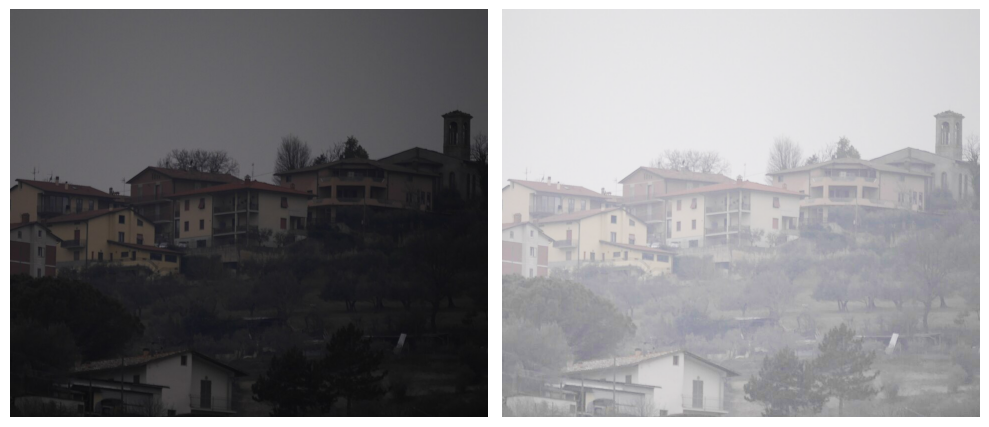

In [23]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('--------------------------------------------------------')

try:
  c = float(input('Masukkan nilai kecerahan:' ))
except ValueError:
  print('Error, not a number')

img = cv.imread('/content/drive/MyDrive/PCVK/houses.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

img_float = img.astype(np.float32)
img_log = c * np.log1p(img_float)

img_hasil = np.clip(img_log, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_hasil, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

4. Implementasikan transformasi grayscale menggunakan metode averaging, lightness,
dan luminance pada Google Colaboratory menggunakan formula yang terdapat pada
bagian Ulasan Teori, sehingga menghasilkan keluaran seperti berikut:

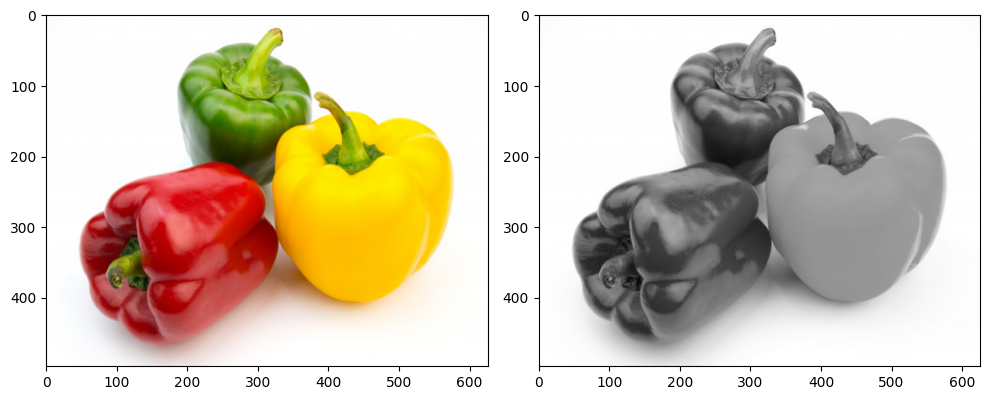

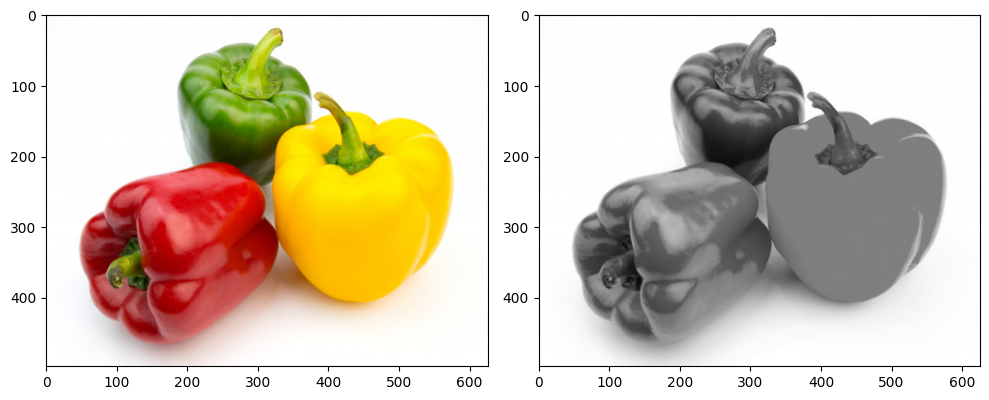

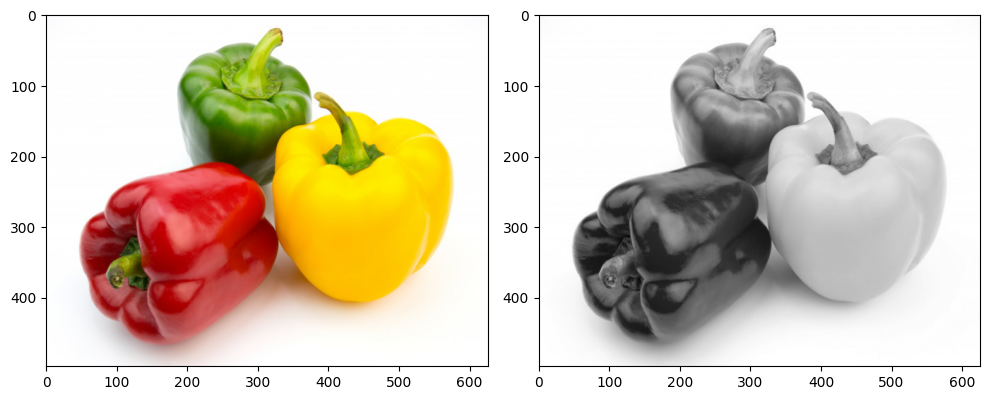

In [24]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread("/content/drive/MyDrive/PCVK/peppers.jpg")
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

R = img_rgb[:, :, 0].astype(np.float32)
G = img_rgb[:, :, 1].astype(np.float32)
B = img_rgb[:, :, 2].astype(np.float32)

# a. Averaging --> Formula: (R + G + B) / 3

gray_avg = ((R + G + B) / 3).astype(np.uint8)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)

plt.subplot(1, 2, 2)
plt.imshow(gray_avg, cmap="gray", vmin=0, vmax=255)

plt.tight_layout()
plt.show()

# b. Lightness --> Formula: (max[R, G, B] + min[R, G, B]) / 2

max_rgb = np.maximum(np.maximum(R, G), B)
min_rgb = np.minimum(np.minimum(R, G), B)
gray_lightness = ((max_rgb + min_rgb) / 2).astype(np.uint8)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)

plt.subplot(1, 2, 2)
plt.imshow(gray_lightness, cmap="gray", vmin=0, vmax=255)

plt.tight_layout()
plt.show()

# c. Luminance

gray_luminance = (0.21 * R + 0.72 * G + 0.07 * B).astype(np.uint8)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)

plt.subplot(1, 2, 2)
plt.imshow(gray_luminance, cmap="gray", vmin=0, vmax=255)

plt.tight_layout()
plt.show()

5. Tampilkanlah warna tertentu pada citra, dan ubah warna lain menjadi grayscale. Misal,
tampilkan warna merah pada citra masukan dan ubah bagian lain yang tidak berwarna
merah menjadi grayscale seperti pada contoh berikut:

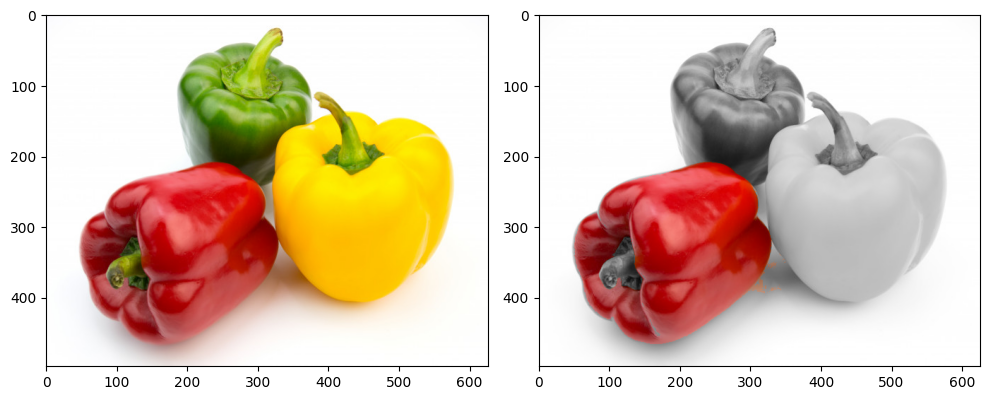

In [25]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread("/content/drive/MyDrive/PCVK/peppers.jpg")
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

img_hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

lower_red1 = np.array([0, 100, 50])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([170, 100, 50])
upper_red2 = np.array([180, 255, 255])

mask1 = cv.inRange(img_hsv, lower_red1, upper_red1)
mask2 = cv.inRange(img_hsv, lower_red2, upper_red2)
red_mask = cv.bitwise_or(mask1, mask2)

gray = cv.cvtColor(img_rgb, cv.COLOR_RGB2GRAY)
gray_3ch = cv.cvtColor(gray, cv.COLOR_GRAY2RGB)

mask_3ch = red_mask == 255
img_hasil = np.where(mask_3ch[:, :, None], img_rgb, gray_3ch)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)

plt.subplot(1, 2, 2)
plt.imshow(img_hasil)

plt.tight_layout()
plt.show()

6. Buat Gamma Correction sesuai dengan petunjuk berikut
Percobaan ini akan meminta anda membuat Gamma Correction. Pada percobaan ini, nilai
Gamma akan diset dengan meminta masukan dari pengguna. Berikut adalah kode untuk
meminta masukan nilai dari pengguna. Lanjutkan kode tersebut dengan membuat image
dengan gamma correction sesuai rumus yang telah diberikan.

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 0.5


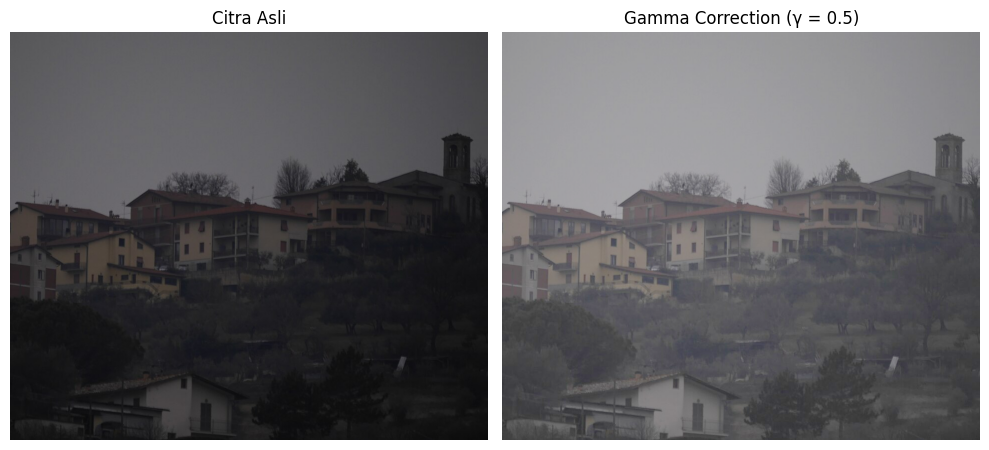

In [28]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
  gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
  print('Error, not a number')

img = cv.imread("/content/drive/MyDrive/PCVK/houses.jpg")
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

img_norm = img_rgb.astype(np.float32) / 255.0
gamma_corrected = 255.0 * (img_norm**gamma)

img_hasil = np.clip(gamma_corrected, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Citra Asli")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_hasil)
plt.title(f"Gamma Correction (γ = {gamma})")
plt.axis("off")

plt.tight_layout()
plt.show()

7. Buat Simulasi Image Depth
Percobaan ini digunakan sebagai simulasi dari proses kuantisasi citra. Pada kuantisasi
citra, pixel dapat direpresentasikan dengan n-bit kedalaman (default menggunakan 8-bit).
Pada pixel 8-bit, warna yang memungkinkan adalah 256 warna, dari 0 (0000 0000) hingga
255(1111 1111). Pada pixel 7-bit, warna yang memungkinkan adalah 128 warna, dari 0
(000 0000) hingga 127 (111 1111). Kemungkinan warna didapat dari pangkat 2 jumlah bit.
Jika 7bit, maka jumlah warnanya adalah 27 = 128, dst.

Masukkan bit depth tujuan (1-8): 3
Bit depth awal  : 8 bit
Bit depth tujuan: 3 bit
Jumlah level    : 8


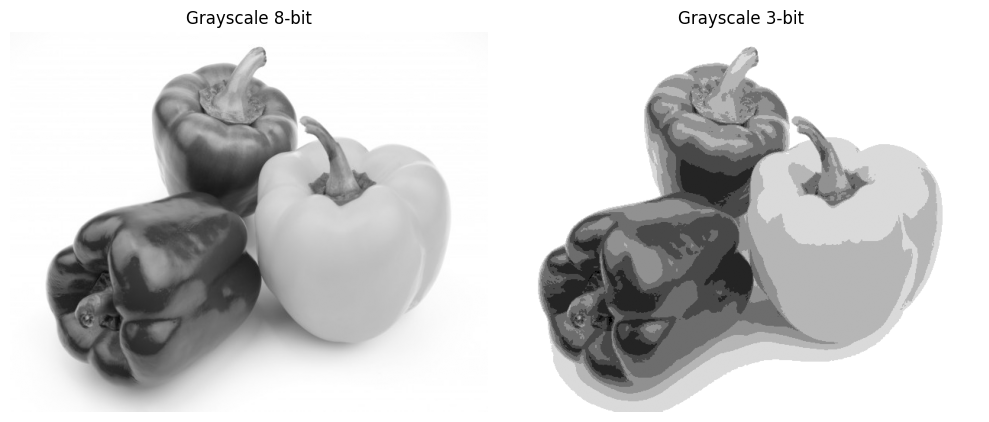

In [31]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

bit_depth = int(input("Masukkan bit depth tujuan (1-8): "))

jumlah_level = pow(2, bit_depth)
print(f"Bit depth awal  : 8 bit")
print(f"Bit depth tujuan: {bit_depth} bit")
print(f"Jumlah level    : {jumlah_level}")

level = 255 / (pow(2, bit_depth) - 1)


original = cv.imread("/content/drive/MyDrive/PCVK/peppers.jpg",cv.IMREAD_GRAYSCALE,)

depth_image = np.round(original / level) * level
depth_image = np.clip(depth_image, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original, cmap="gray", vmin=0, vmax=255)
plt.title("Grayscale 8-bit")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(depth_image, cmap="gray", vmin=0, vmax=255)
plt.title(f"Grayscale {bit_depth}-bit")
plt.axis("off")

plt.tight_layout()
plt.show()

8. Buat modul Average Denoising
Buat modul average denoising sesuai dengan rumus yang telah diberikan pada sub bab
sebelumnya.

Total citra bernoise yang dimuat: 100
Jumlah Citra: 10  | Nilai PSNR: 19.74 dB
Jumlah Citra: 20  | Nilai PSNR: 19.84 dB
Jumlah Citra: 40  | Nilai PSNR: 19.89 dB
Jumlah Citra: 80  | Nilai PSNR: 19.92 dB
Jumlah Citra: 100 | Nilai PSNR: 19.92 dB


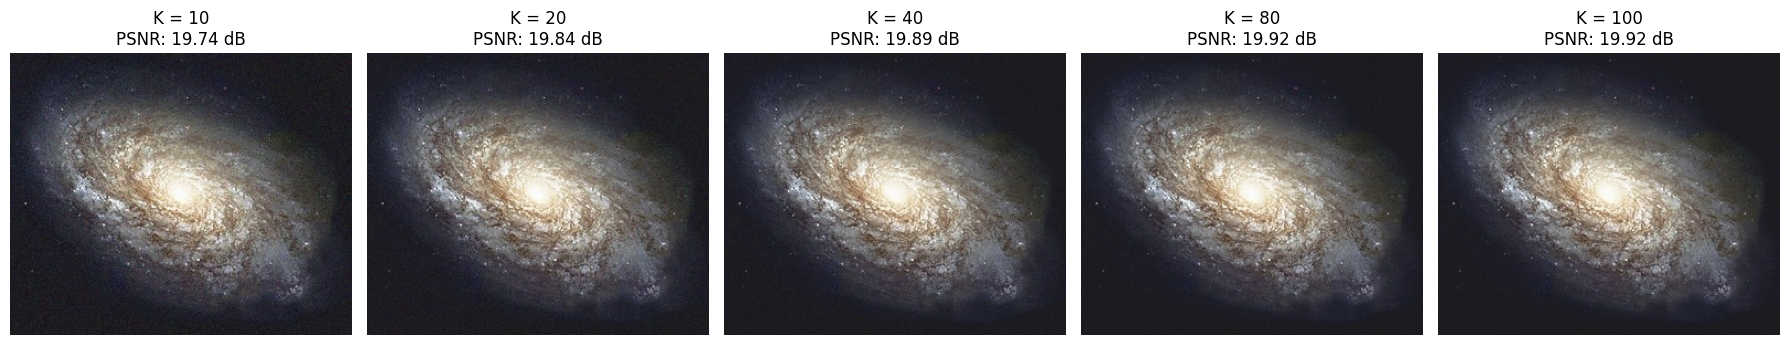

In [35]:
import glob
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

path_asli = "/content/drive/MyDrive/PCVK/galaxy.jpg"
original = cv.imread(path_asli)

if original is None:
    raise FileNotFoundError("Citra asli galaxy.jpg tidak ditemukan!")

original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

path_noises = ("/content/drive/MyDrive/PCVK/images/*.jpg")
files = sorted(glob.glob(path_noises))

cv_img = []
for file in files:
    n = cv.imread(file)
    if n is not None:
        cv_img.append(cv.cvtColor(n, cv.COLOR_BGR2RGB))

print(f"Total citra bernoise yang dimuat: {len(cv_img)}")

jumlah_citra = [10, 20, 40, 80, 100]
hasil_denoised = []
nilai_psnr = []

for k in jumlah_citra:
    subset = np.array(cv_img[:k], dtype=np.float32)

    avg_img = np.mean(subset, axis=0)
    avg_img = np.clip(avg_img, 0, 255).astype(np.uint8)

    psnr = cv.PSNR(original_rgb, avg_img)

    hasil_denoised.append(avg_img)
    nilai_psnr.append(psnr)

    print(f"Jumlah Citra: {k:<3} | Nilai PSNR: {psnr:.2f} dB")

plt.figure(figsize=(18, 4))
for i, k in enumerate(jumlah_citra):
    plt.subplot(1, len(jumlah_citra), i + 1)
    plt.imshow(hasil_denoised[i])
    plt.title(f"K = {k}\nPSNR: {nilai_psnr[i]:.2f} dB")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Apakah peningkatan jumlah citra selalu memberikan peningkatan PSNR yang signifikan?**

Tidak. Peningkatan nilai PSNR sangat drastis pada tahap awal (misalnya dari citra tunggal ke 10 dan 20 citra), tetapi laju peningkatannya melambat secara eksponensial seiring bertambahnya jumlah citra.

**Pada jumlah citra berapa peningkatan mulai tidak terlalu signifikan?**

Mulai rentang 40 citra ke atas (antara 40, 80, hingga 100 citra). Selisih kenaikan dB sudah sangat tipis dan perbedaan kualitas visualnya hampir tidak kasat mata.

9. Buat image masking
Buat image masking untuk image berikut. Image kiri adalah image asli (images/couple.tiff),
sedangkan image paling kanan adalah hasilnya:

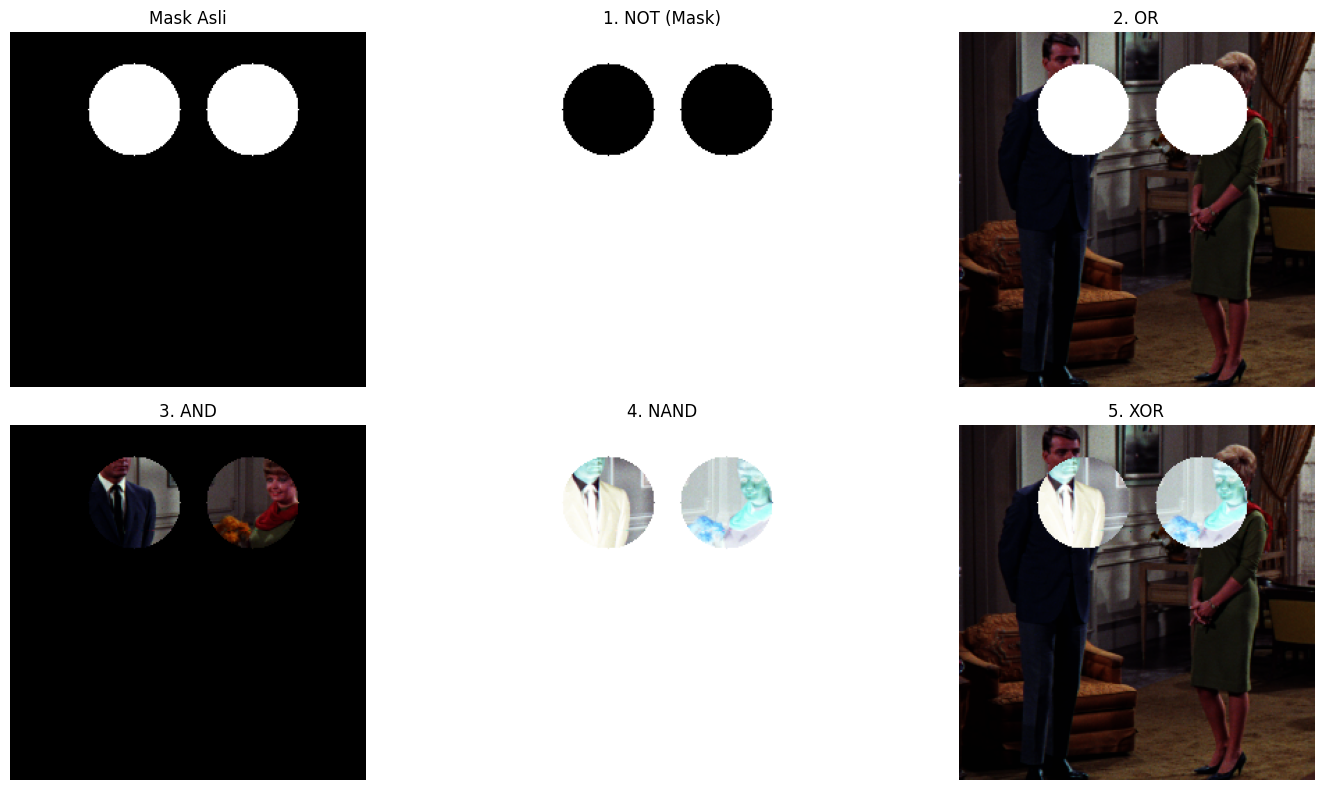

In [36]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread("/content/drive/MyDrive/PCVK/couple.tiff")

img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
h, w, _ = img_rgb.shape

mask = np.zeros((h, w), dtype=np.uint8)

cv.circle(mask, (int(w * 0.35), int(h * 0.22)), int(w * 0.13), 255, -1)
cv.circle(mask, (int(w * 0.68), int(h * 0.22)), int(w * 0.13), 255, -1)

mask_3ch = cv.merge([mask, mask, mask])

out_not_mask = cv.bitwise_not(mask_3ch)
out_not_img = cv.bitwise_not(img_rgb)

out_or = cv.bitwise_or(img_rgb, mask_3ch)

out_and = cv.bitwise_and(img_rgb, mask_3ch)

out_nand = cv.bitwise_not(out_and)

out_xor = cv.bitwise_xor(img_rgb, mask_3ch)

opsi_tampil = [
    ("Mask Asli", mask),
    ("1. NOT (Mask)", out_not_mask),
    ("2. OR", out_or),
    ("3. AND", out_and),
    ("4. NAND", out_nand),
    ("5. XOR", out_xor),
]

plt.figure(figsize=(15, 8))
for i, (judul, hasil) in enumerate(opsi_tampil):
    plt.subplot(2, 3, i + 1)
    if len(hasil.shape) == 2:
        plt.imshow(hasil, cmap="gray")
    else:
        plt.imshow(hasil)
    plt.title(judul)
    plt.axis("off")

plt.tight_layout()
plt.show()

Citra keluaran dipengaruhi langsung oleh representasi biner dari piksel citra masukan terhadap nilai piksel pada mask (nilai 255/1 untuk warna putih dan 0 untuk warna hitam)
1. Operator AND (Dan) menghasilkan citra masking standar: area di dalam lingkaran bernilai 255 sehingga nilai piksel asli dipertahankan ($I \text{ AND } 255 = I$), sedangkan area di luar lingkaran bernilai 0 sehingga nilai piksel diubah menjadi hitam pekat ($I \text{ AND } 0 = 0).
2. Operator OR (Atau) membuat area di dalam lingkaran menjadi putih maksimal atau jenuh ($I \text{ OR } 255 = 255$), sementara area di luar lingkaran tetap mempertahankan warna citra aslinya ($I \text{ OR } 0 = I$).
3. Operator NOT (Komplemen) membalik intensitas seluruh piksel citra ($255 - I$), sehingga menghasilkan efek klise negatif; bagian gelap menjadi terang dan bagian terang menjadi gelap.
4. Operator NAND (Not AND) merupakan kebalikan langsung dari operasi AND; area luar lingkaran menjadi putih pekat ($255$), sedangkan area dalam lingkaran menampilkan citra negatif dari objek aslinya.
5. Operator XOR (Exclusive OR) mempertahankan citra asli pada area berlatar hitam ($I \oplus 0 = I$), tetapi membalik warna piksel menjadi negatif pada area di dalam lingkaran yang bernilai putih ($I \oplus 255 = \sim I$). *italicized text*

10. Foto Malam Hari
Carilah foto malam hari yang gelap. Namun, beberapa bagian gambar memiliki detail yang
sebenarnya cukup baik. Pilih salah satu metode berikut dan implementasikan pada foto
tersebut (Linear Brightness, Contrast, Logarithmic Brightness, Gamma Correction). Sebutkan
alasan dan resiko metode yang Anda gunakan.

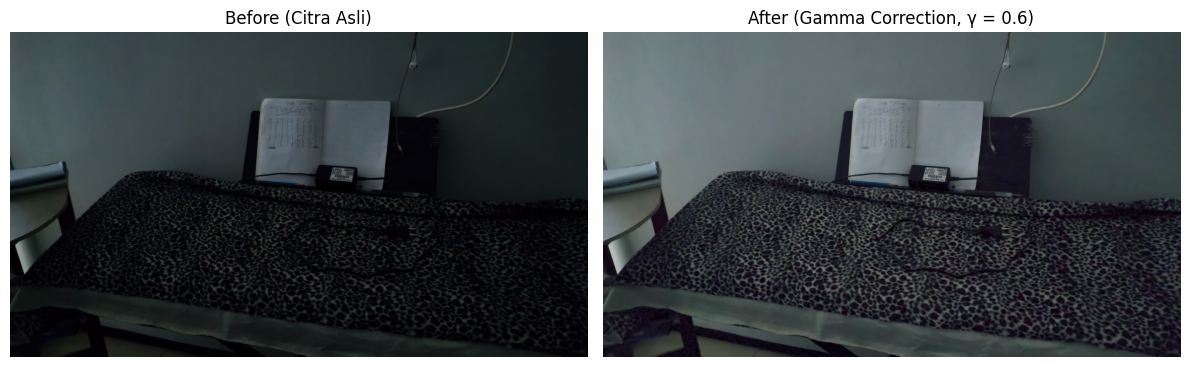

In [47]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread("/content/drive/MyDrive/PCVK/malam.jpg" )
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# 2. Implementasi Gamma Correction
# Nilai gamma < 1 (contoh: 0.55 - 0.65) untuk mengangkat detail gelap tanpa merusak area terang
gamma = 0.6

# Normalisasi rentang ke [0.0, 1.0], lakukan perpangkatan, lalu kalikan kembali 255
img_norm = img_rgb.astype(np.float32) / 255.0
gamma_corrected = 255.0 * (img_norm**gamma)
img_hasil = np.clip(gamma_corrected, 0, 255).astype(np.uint8)

# 3. Tampilkan perbandingan Sebelum (Before) dan Sesudah (After)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Before (Citra Asli)", fontsize=12)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_hasil)
plt.title(f"After (Gamma Correction, γ = {gamma})", fontsize=12)
plt.axis("off")

plt.tight_layout()
plt.show()

11. Perbaiki kualitas pada citra tersebut dengan metode operasi dasar citra apapun.
Diperbolehkan menggunakan lebih dari 1 metode. Kemudian jelaskan:
• Metode yang dipilih
• Alasan pemilihan
• Menentukan parameter terbaik
• Menghasilkan citra dengan menunjukkan before-after.

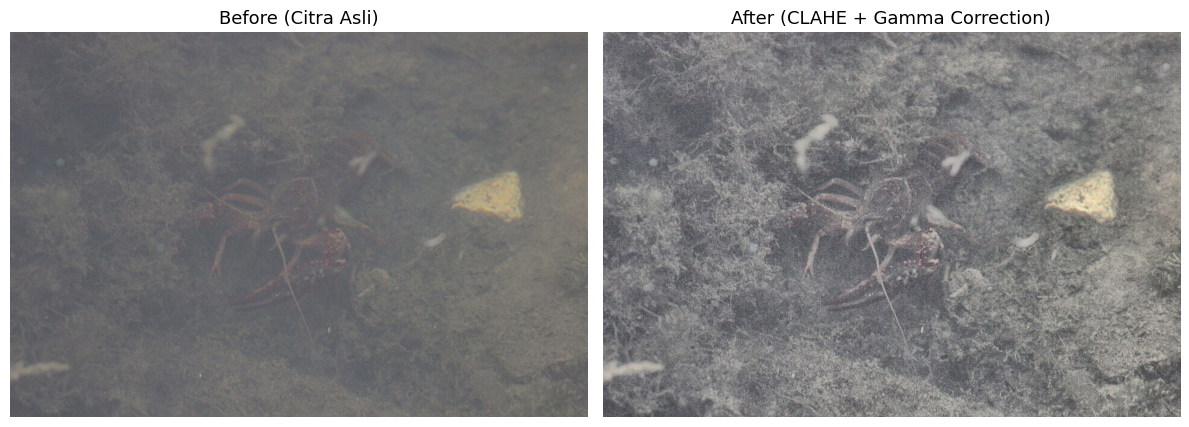

In [38]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

path_gambar = "/content/drive/MyDrive/PCVK/crayfish.jpg"
img = cv.imread(path_gambar)

img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

img_lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)
l_channel, a_channel, b_channel = cv.split(img_lab)

clahe = cv.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
cl = clahe.apply(l_channel)

merged_lab = cv.merge((cl, a_channel, b_channel))
img_clahe = cv.cvtColor(merged_lab, cv.COLOR_LAB2RGB)

gamma = 0.85
img_norm = img_clahe.astype(np.float32) / 255.0
img_hasil = np.clip(255.0 * (img_norm**gamma), 0, 255).astype(np.uint8)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Before (Citra Asli)", fontsize=13)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_hasil)
plt.title("After (CLAHE + Gamma Correction)", fontsize=13)
plt.axis("off")

plt.tight_layout()
plt.show()